C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


ARI without PCA: 0.7163421126838476
ARI with PCA: 0.7163421126838476


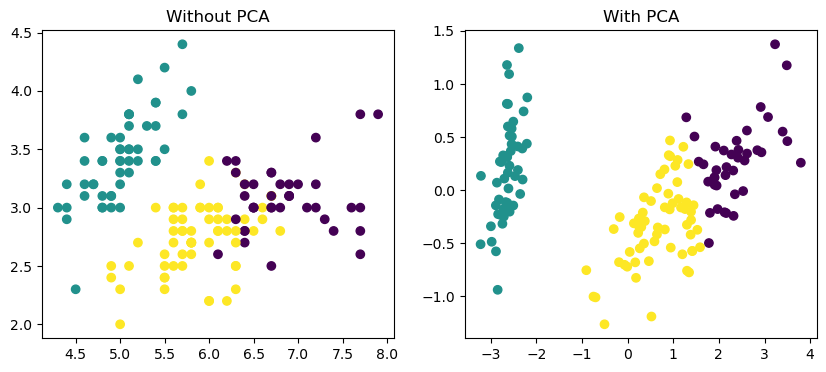

In [3]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
data = load_iris()
X = data.data
y = data.target

# Without PCA
kmeans1 = KMeans(n_clusters=3)
labels1 = kmeans1.fit_predict(X)
ari1 = adjusted_rand_score(y, labels1)

# With PCA
pipe = Pipeline([
    ('pca', PCA(n_components=2)),
    ('kmeans', KMeans(n_clusters=3))
])

labels2 = pipe.fit_predict(X)
ari2 = adjusted_rand_score(y, labels2)

print("ARI without PCA:", ari1)
print("ARI with PCA:", ari2)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=labels1)
plt.title("Without PCA")

X_pca = PCA(n_components=2).fit_transform(X)

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels2)
plt.title("With PCA")

plt.show()